# 02 — Visualization

Loads `results_clean.csv` (mean per language × benchmark) and produces thesis-ready charts.

Charts produced:
- **Heatmaps** — energy / time / carbon per language × benchmark
- **Bar charts** — total energy & carbon ranked by language
- **Scatter** — energy vs. execution time (efficiency view)
- **Stacked bar** — CPU vs. memory energy breakdown per language

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

RUNS_CSV = Path('../results/results_clean_runs.csv')
FIGS_DIR  = Path('../results/figs')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Thesis-friendly style
plt.rcParams.update({
    'font.family'     : 'serif',
    'font.size'       : 10,
    'axes.titlesize'  : 11,
    'axes.labelsize'  : 10,
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'savefig.format'  : 'pdf',
})

In [2]:
_runs = pd.read_csv(RUNS_CSV)
_id_cols = {'run_id', 'measured_at', 'language', 'benchmark'}
_metric_cols = [c for c in _runs.columns if c not in _id_cols]
df = _runs.groupby(['language', 'benchmark'])[_metric_cols].mean().reset_index()
print(f'Shape: {df.shape}')
df.head(3)
LANG_DISPLAY = {
    'c': 'C', 'cpp': 'C++', 'csharp': 'C#', 'fsharp': 'F#',
    'nodejs': 'JavaScript', 'dart': 'Dart', 'erlang': 'Erlang',
    'go': 'Go', 'haskell': 'Haskell', 'java': 'Java', 'lua': 'Lua',
    'ocaml': 'OCaml', 'perl': 'Perl', 'php': 'PHP',
    'python': 'Python', 'ruby': 'Ruby', 'rust': 'Rust', 'swift': 'Swift',
}
df['language'] = df['language'].replace(LANG_DISPLAY)

Shape: (144, 14)


In [3]:
# Convenience: list the available metric columns with their units
METRIC_COLS = [c for c in df.columns if c not in ('language', 'benchmark')]
print('\n'.join(METRIC_COLS))

cpu_carbon_rapl_msr_component-package_0-g
cpu_energy_rapl_msr_component-package_0-j
disk_total_read_cgroup_container-container-mb
disk_total_write_cgroup_container-container-mb
embodied_carbon_share_machine-system-g
memory_carbon_rapl_msr_component-dram_0-g
memory_energy_rapl_msr_component-dram_0-j
network_carbon_formula_global-formula-g
network_energy_formula_global-formula-j
network_power_formula_global-formula-w
network_total_cgroup_container-container-mb
phase_time_syscall_system-system-ms


---
## Helper — pivot to language × benchmark matrix

In [4]:
def pivot(metric: str) -> pd.DataFrame:
    return df.pivot(index='language', columns='benchmark', values=metric)

def save(name: str):
    plt.savefig(FIGS_DIR / f'{name}.pdf', bbox_inches='tight')
    plt.show()

---
## 1. Heatmaps — energy, time, carbon

In [5]:
# Detect the exact column names (suffix may vary)
def find_col(keyword: str) -> str:
    matches = [c for c in METRIC_COLS if keyword in c]
    if not matches:
        raise KeyError(f'No column matching "{keyword}"')
    return matches[0]

COL_CPU_ENERGY = find_col('cpu_energy')
COL_TIME       = find_col('phase_time')
COL_CPU_CARBON = find_col('cpu_carbon')
COL_MEM_ENERGY = find_col('memory_energy')
COL_MEM_CARBON = find_col('memory_carbon')

print(COL_CPU_ENERGY, COL_TIME, COL_CPU_CARBON)

cpu_energy_rapl_msr_component-package_0-j phase_time_syscall_system-system-ms cpu_carbon_rapl_msr_component-package_0-g


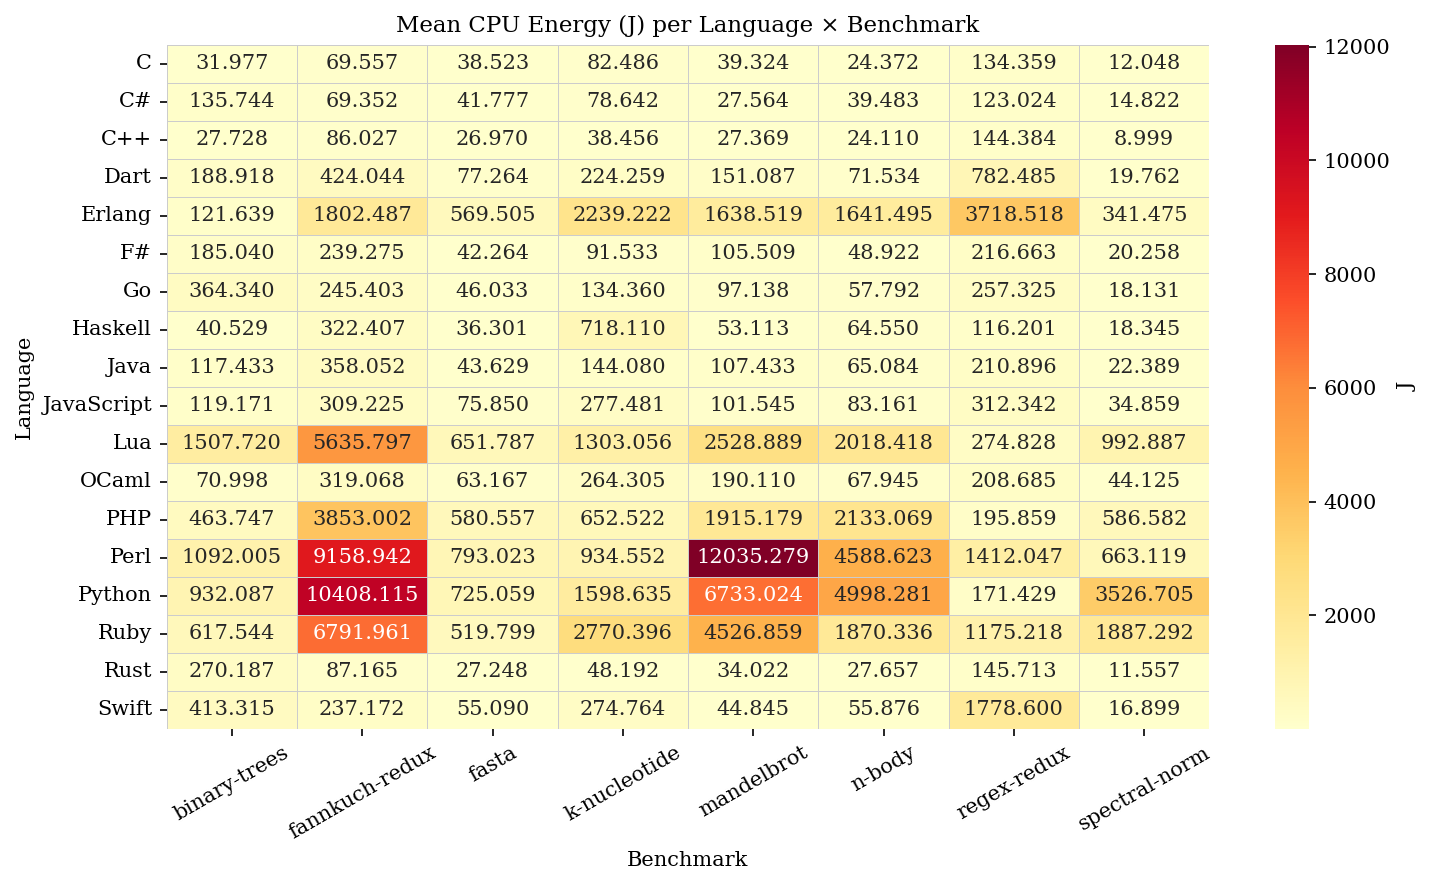

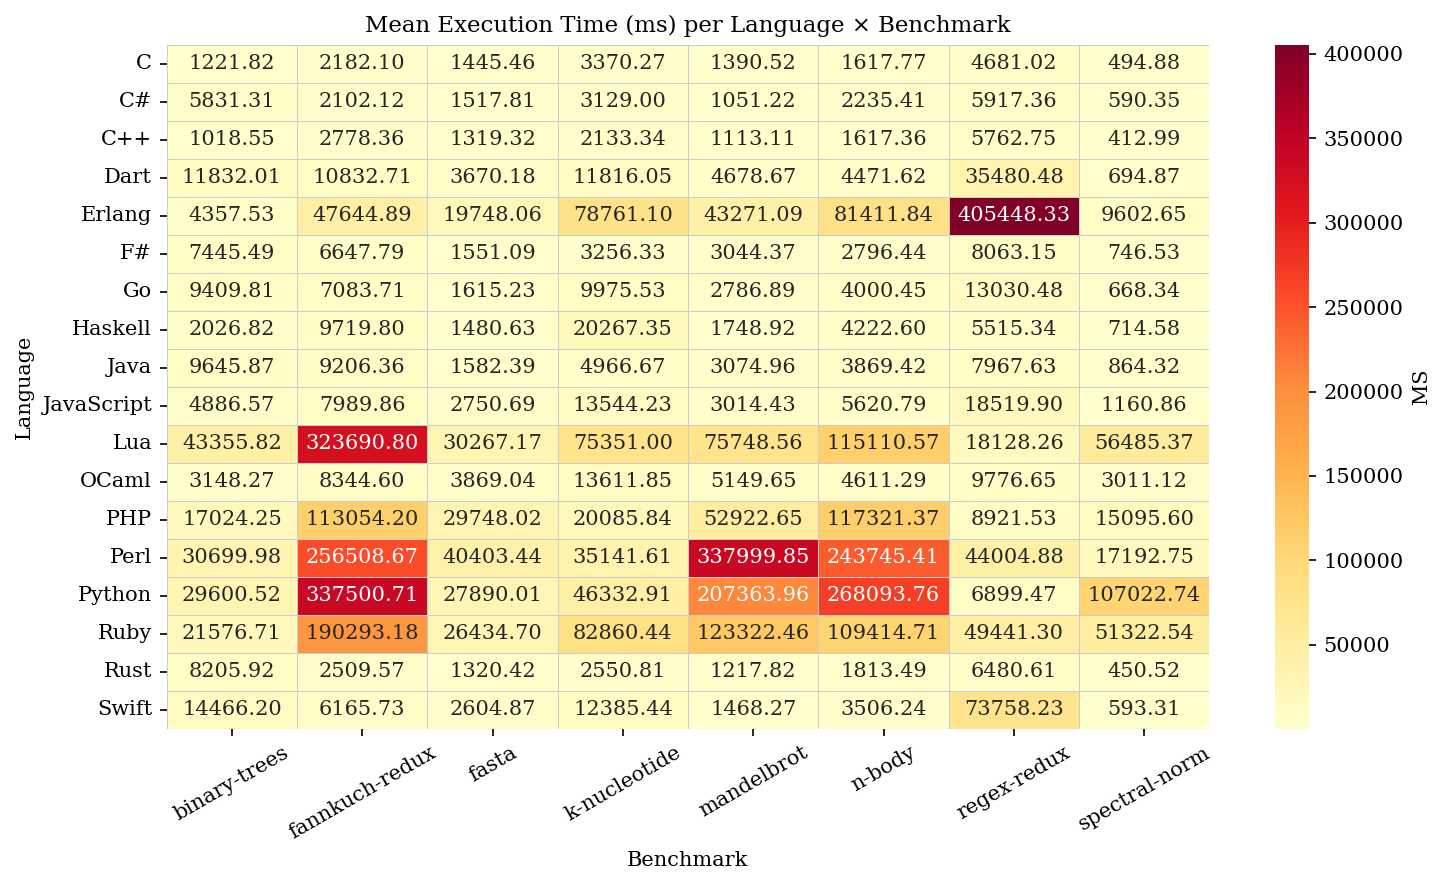

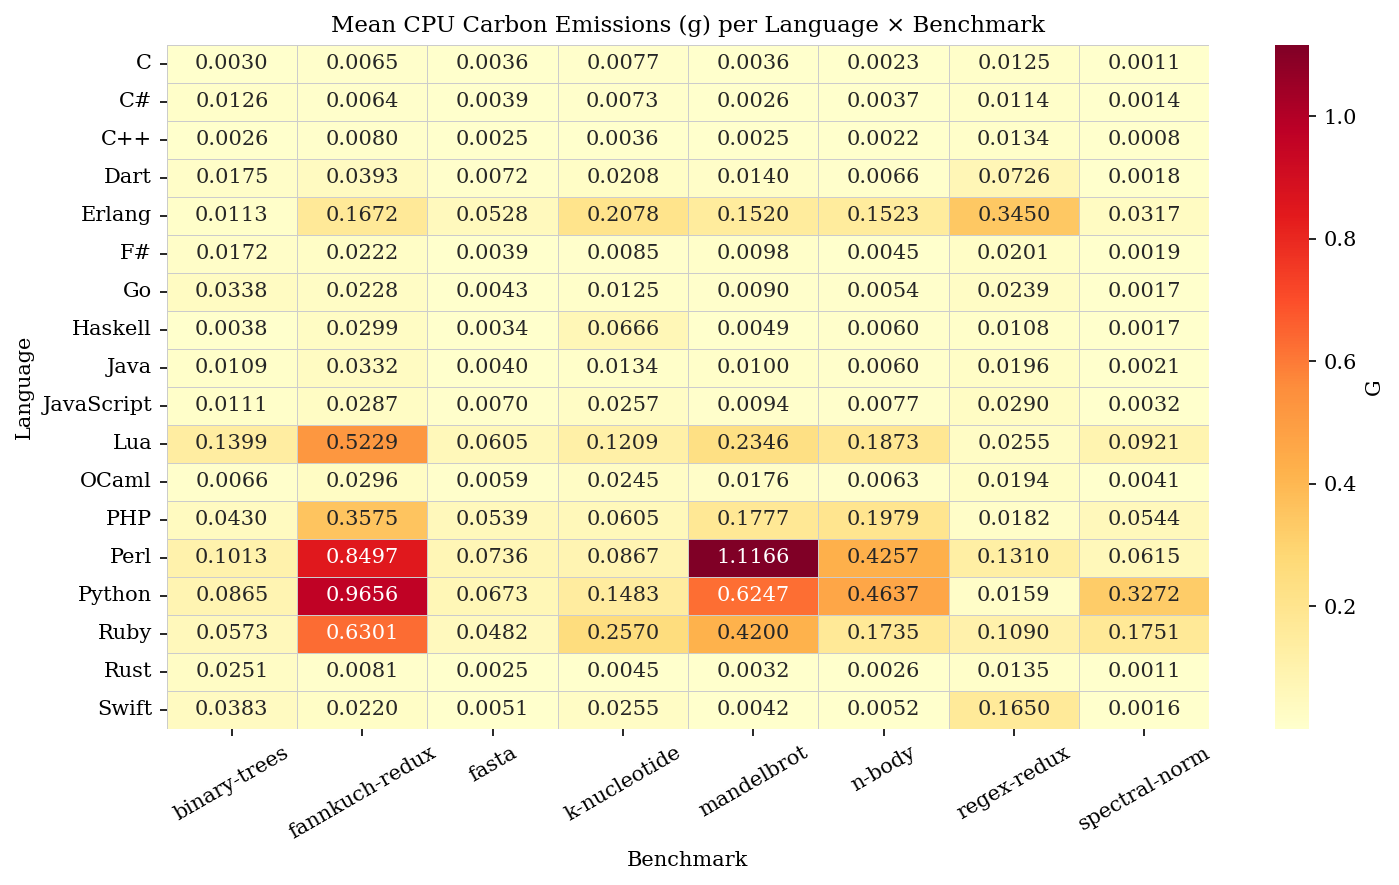

In [6]:
def heatmap(metric_col: str, title: str, fmt: str = '.2f', fname: str = None):
    mat = pivot(metric_col)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(
        mat, annot=True, fmt=fmt, cmap='YlOrRd',
        linewidths=0.4, linecolor='#cccccc',
        cbar_kws={'label': metric_col.split('-')[-1].upper()},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Language')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    save(fname or f'heatmap_{metric_col}')

heatmap(COL_CPU_ENERGY, 'Mean CPU Energy (J) per Language × Benchmark', fmt='.3f', fname='heatmap_cpu_energy')
heatmap(COL_TIME,       'Mean Execution Time (ms) per Language × Benchmark', fmt='.2f', fname='heatmap_time')
heatmap(COL_CPU_CARBON, 'Mean CPU Carbon Emissions (g) per Language × Benchmark', fmt='.4f', fname='heatmap_cpu_carbon')

---
## 2. Ranked bar charts — total energy & carbon across all benchmarks

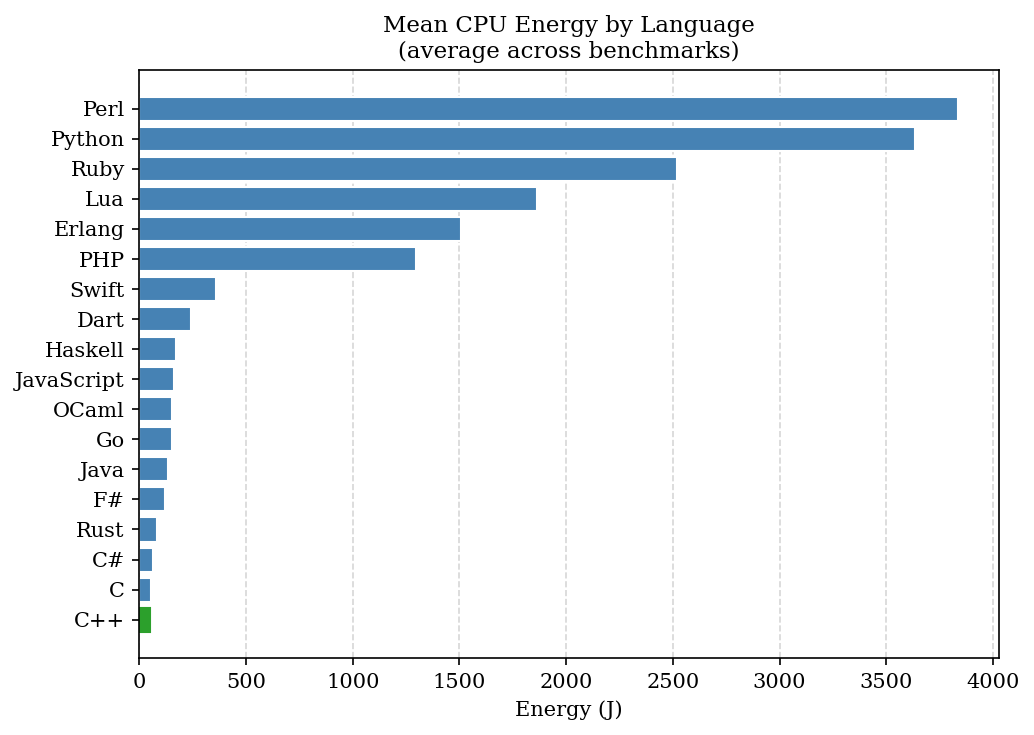

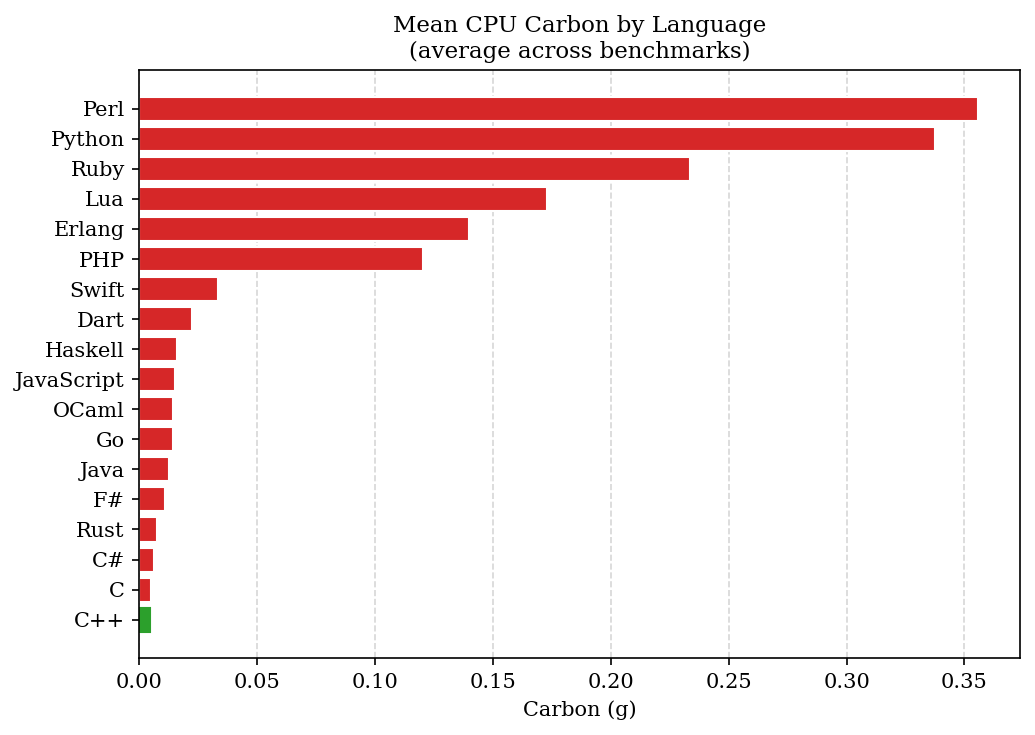

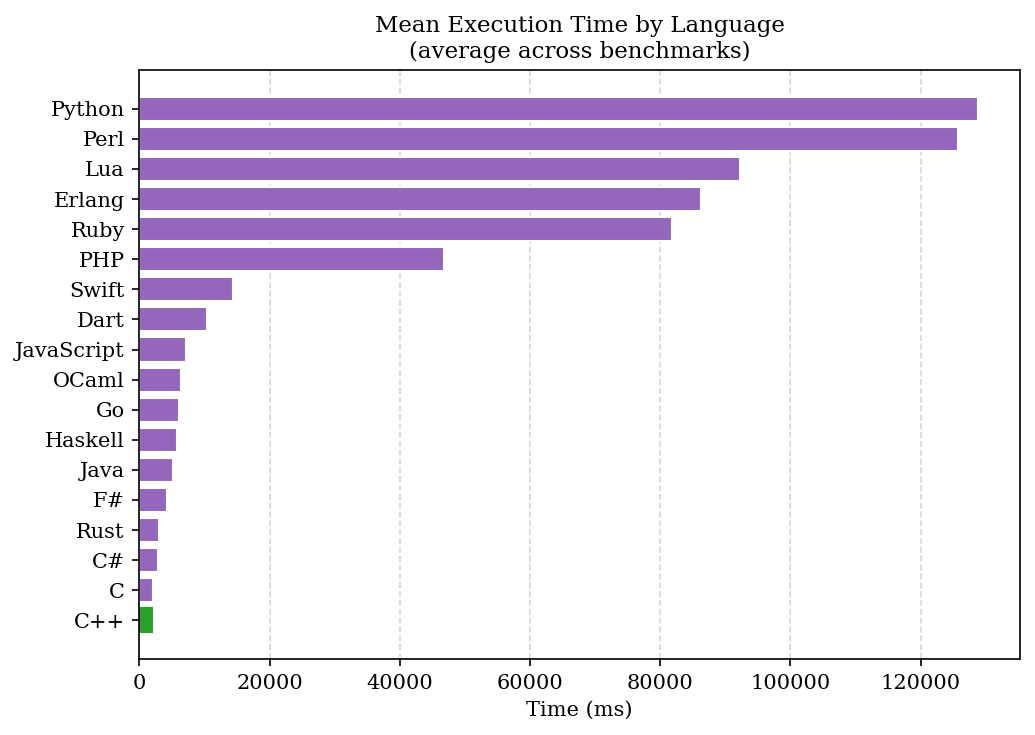

In [7]:
def ranked_bar(metric_col: str, title: str, xlabel: str, fname: str, color: str = 'steelblue'):
    totals = df.groupby('language')[metric_col].mean().sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.barh(totals.index, totals.values, color=color, edgecolor='white')
    # Highlight the best (lowest) bar
    bars[0].set_color('#2ca02c')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    plt.tight_layout()
    save(fname)

ranked_bar(COL_CPU_ENERGY, 'Mean CPU Energy by Language\n(average across benchmarks)', 'Energy (J)', 'bar_cpu_energy')
ranked_bar(COL_CPU_CARBON, 'Mean CPU Carbon by Language\n(average across benchmarks)', 'Carbon (g)', 'bar_cpu_carbon', color='#d62728')
ranked_bar(COL_TIME,       'Mean Execution Time by Language\n(average across benchmarks)', 'Time (ms)',   'bar_time',      color='#9467bd')

---
## 3. Scatter — Energy vs. Execution Time (efficiency quadrant)

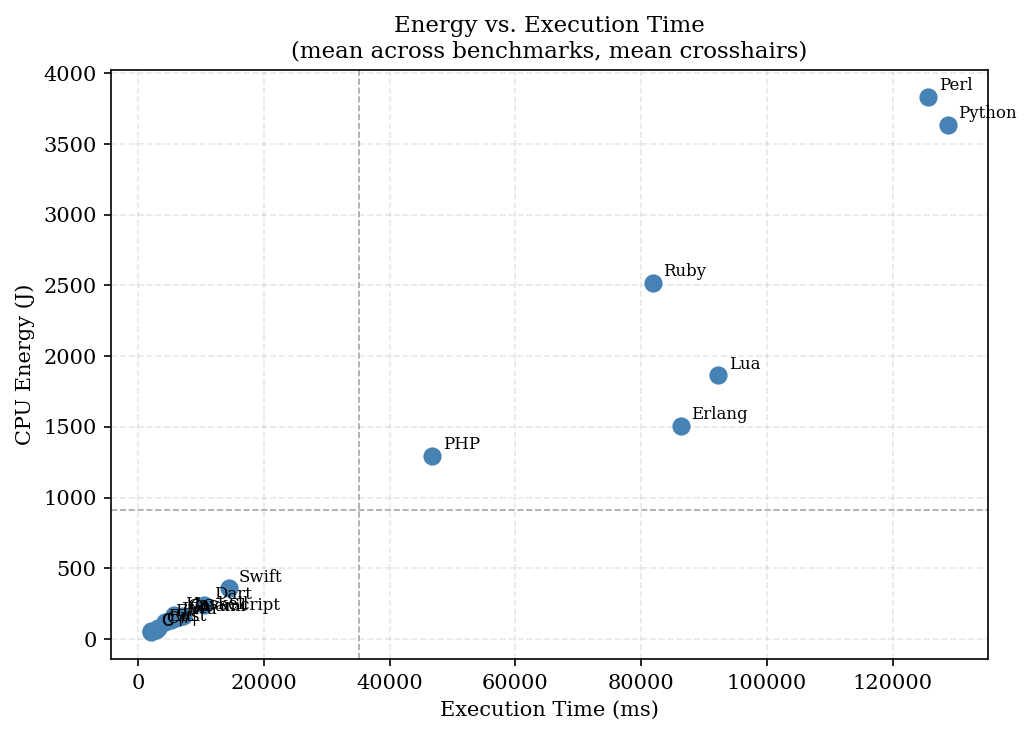

In [8]:
agg = df.groupby('language')[[COL_CPU_ENERGY, COL_TIME]].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(agg[COL_TIME], agg[COL_CPU_ENERGY], s=60, zorder=3, color='steelblue')

for lang, row in agg.iterrows():
    ax.annotate(
        lang,
        (row[COL_TIME], row[COL_CPU_ENERGY]),
        textcoords='offset points', xytext=(5, 3),
        fontsize=8,
    )

# Mean crosshairs
ax.axvline(agg[COL_TIME].mean(), color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(agg[COL_CPU_ENERGY].mean(), color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel('Execution Time (ms)')
ax.set_ylabel('CPU Energy (J)')
ax.set_title('Energy vs. Execution Time\n(mean across benchmarks, mean crosshairs)')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save('scatter_energy_vs_time')

---
## 4. Stacked bar — CPU vs. Memory energy breakdown per language

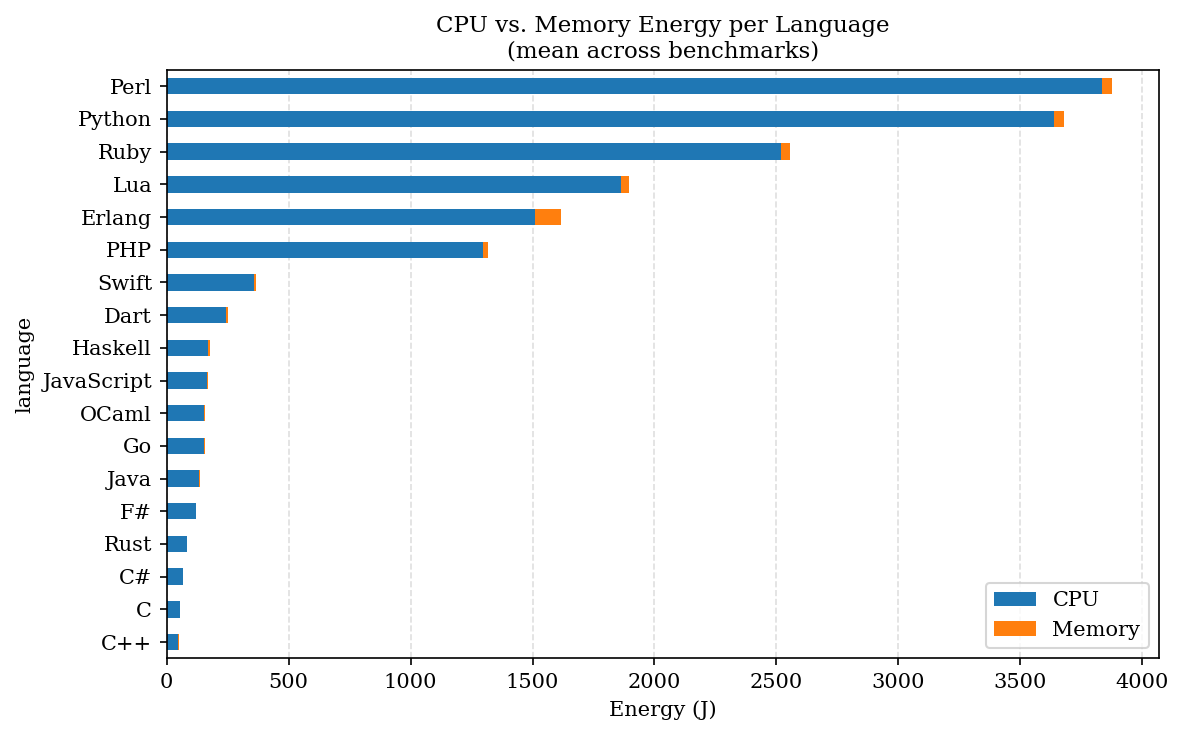

In [9]:
breakdown = (
    df.groupby('language')[[COL_CPU_ENERGY, COL_MEM_ENERGY]]
      .mean()
      .sort_values(COL_CPU_ENERGY)
)

fig, ax = plt.subplots(figsize=(8, 5))
breakdown[COL_CPU_ENERGY].plot(kind='barh', ax=ax, color='#1f77b4', label='CPU')
breakdown[COL_MEM_ENERGY].plot(kind='barh', ax=ax, color='#ff7f0e', left=breakdown[COL_CPU_ENERGY], label='Memory')

ax.set_xlabel('Energy (J)')
ax.set_title('CPU vs. Memory Energy per Language\n(mean across benchmarks)')
ax.legend(loc='lower right')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('stacked_energy_cpu_mem')

---
## 5. Normalized ranking table — Energy & Time (mean across all benchmarks)

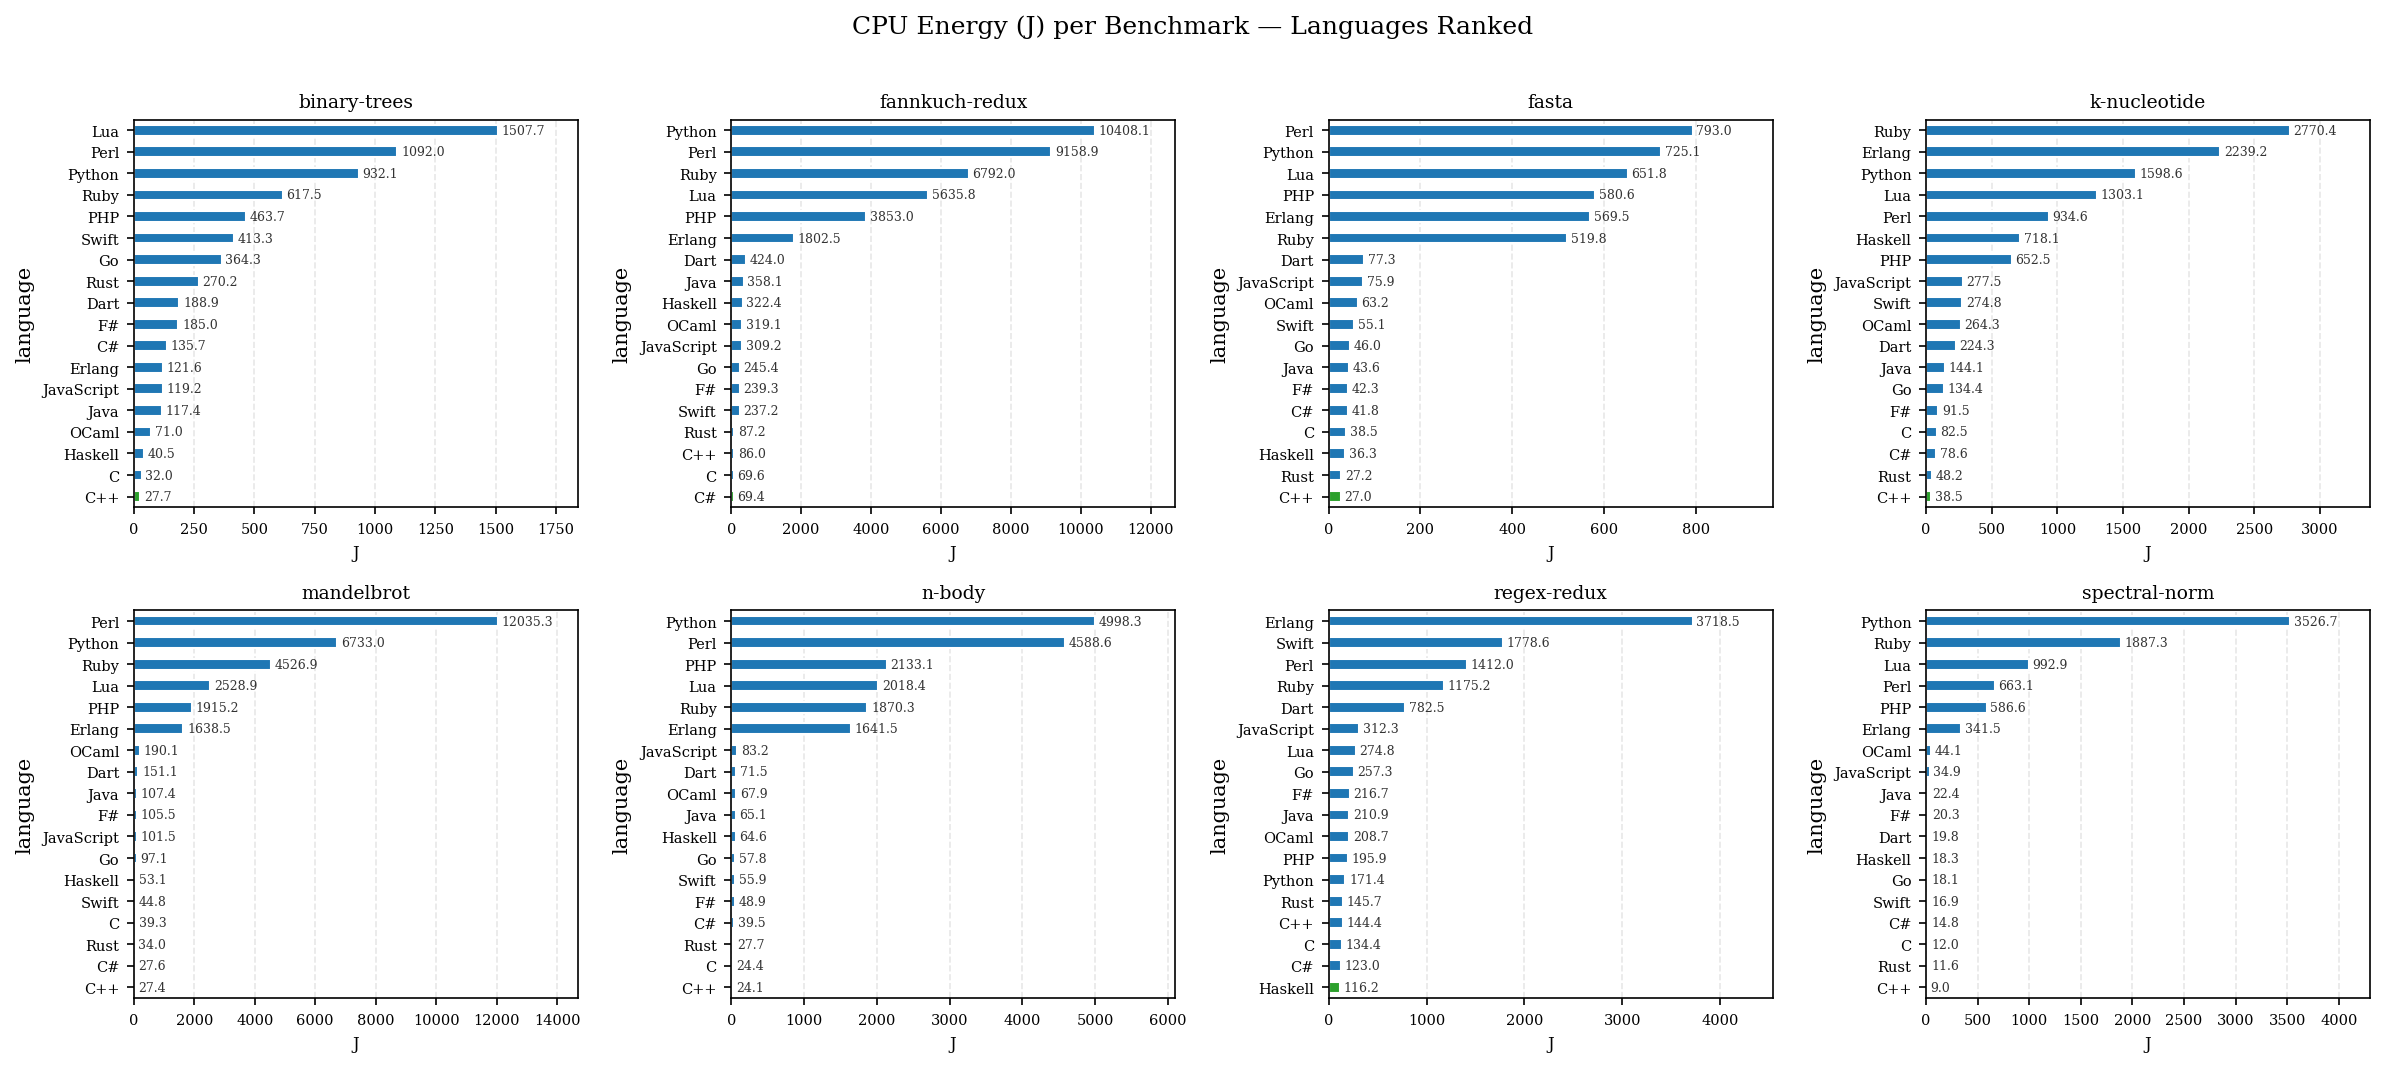

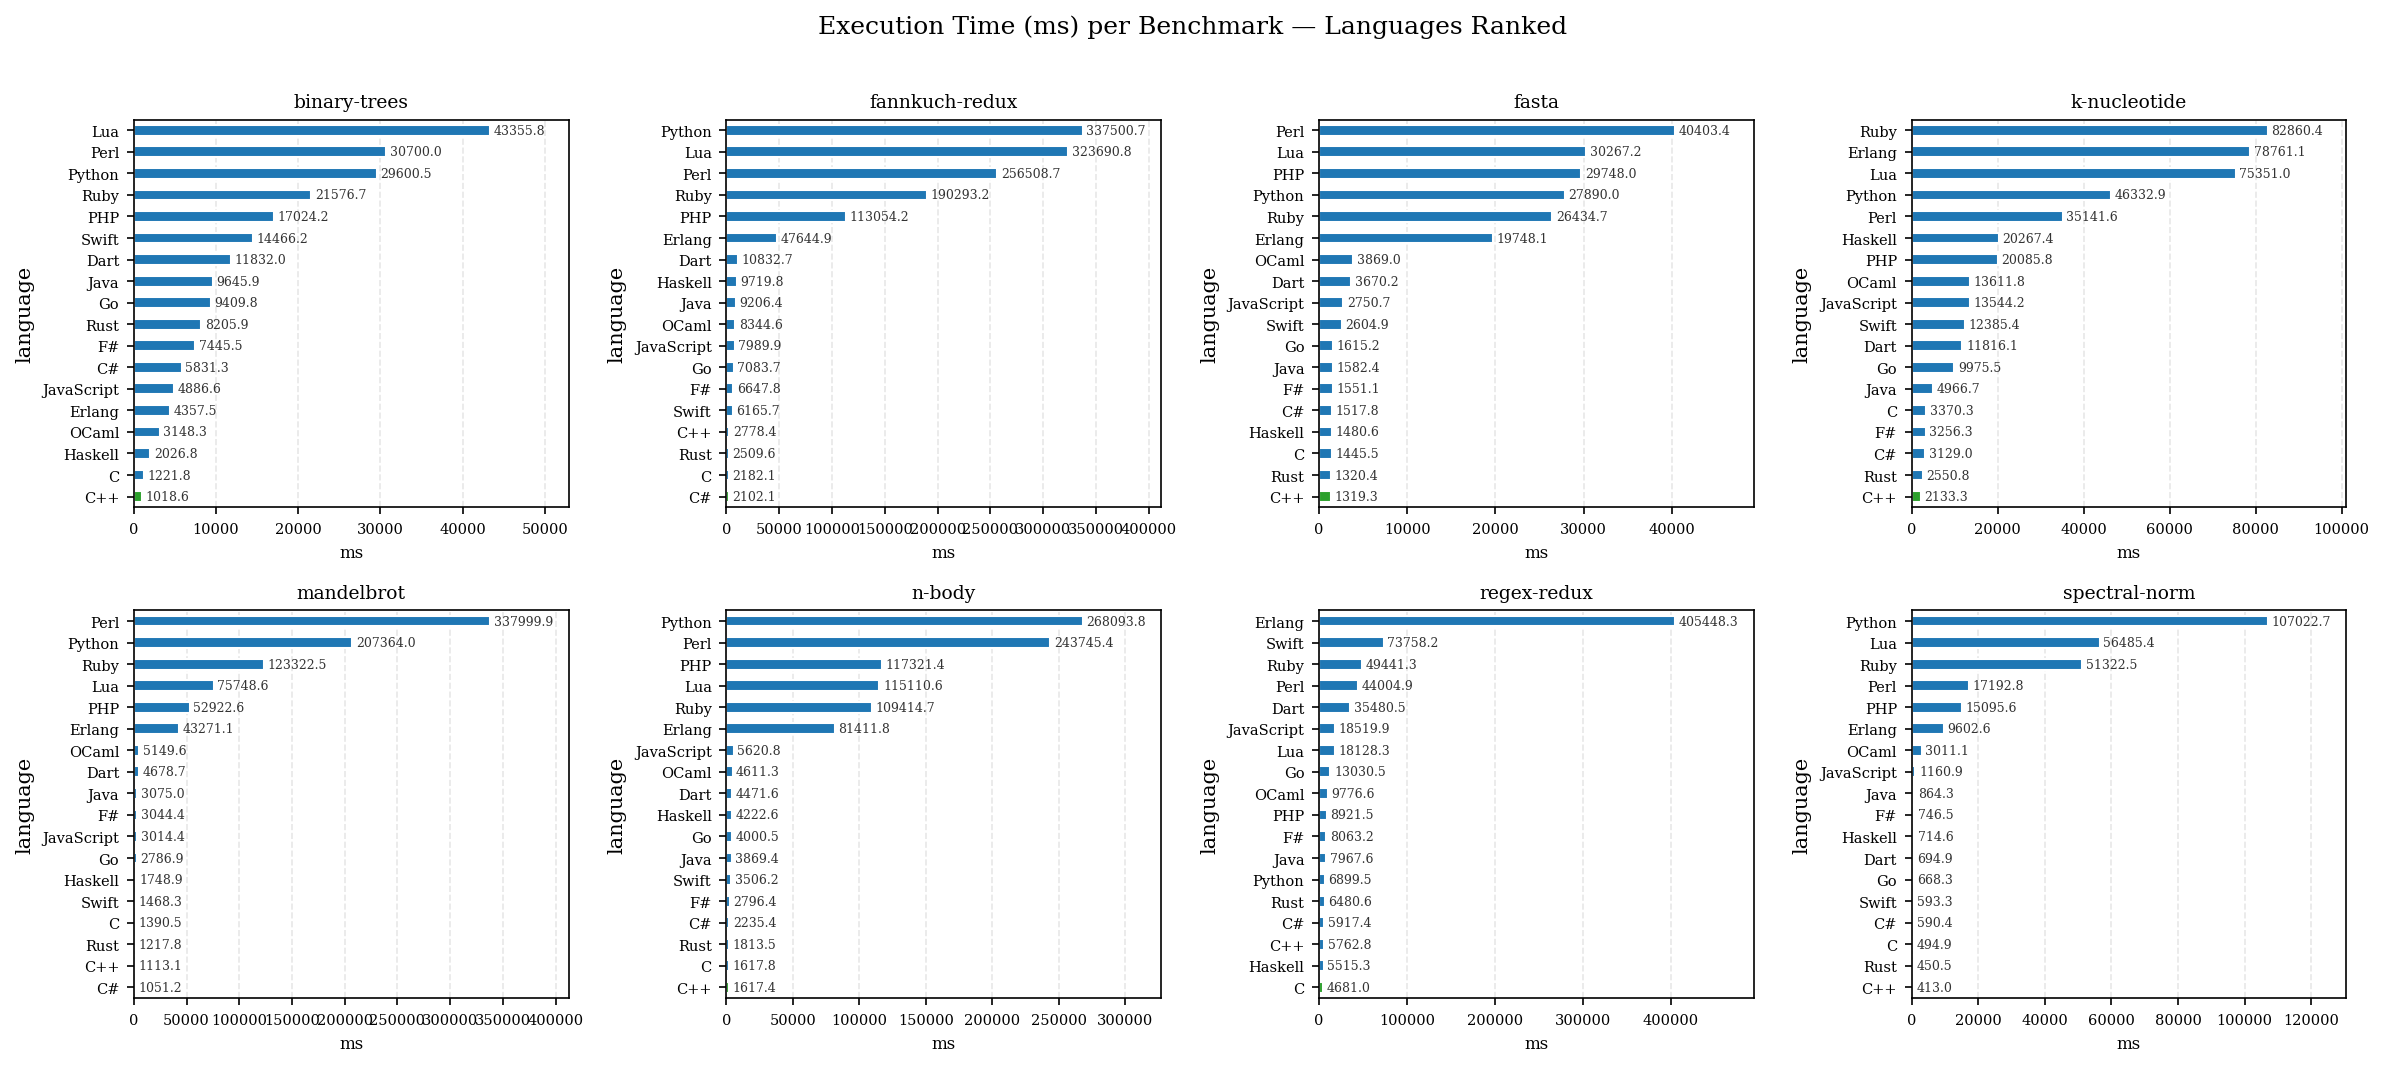

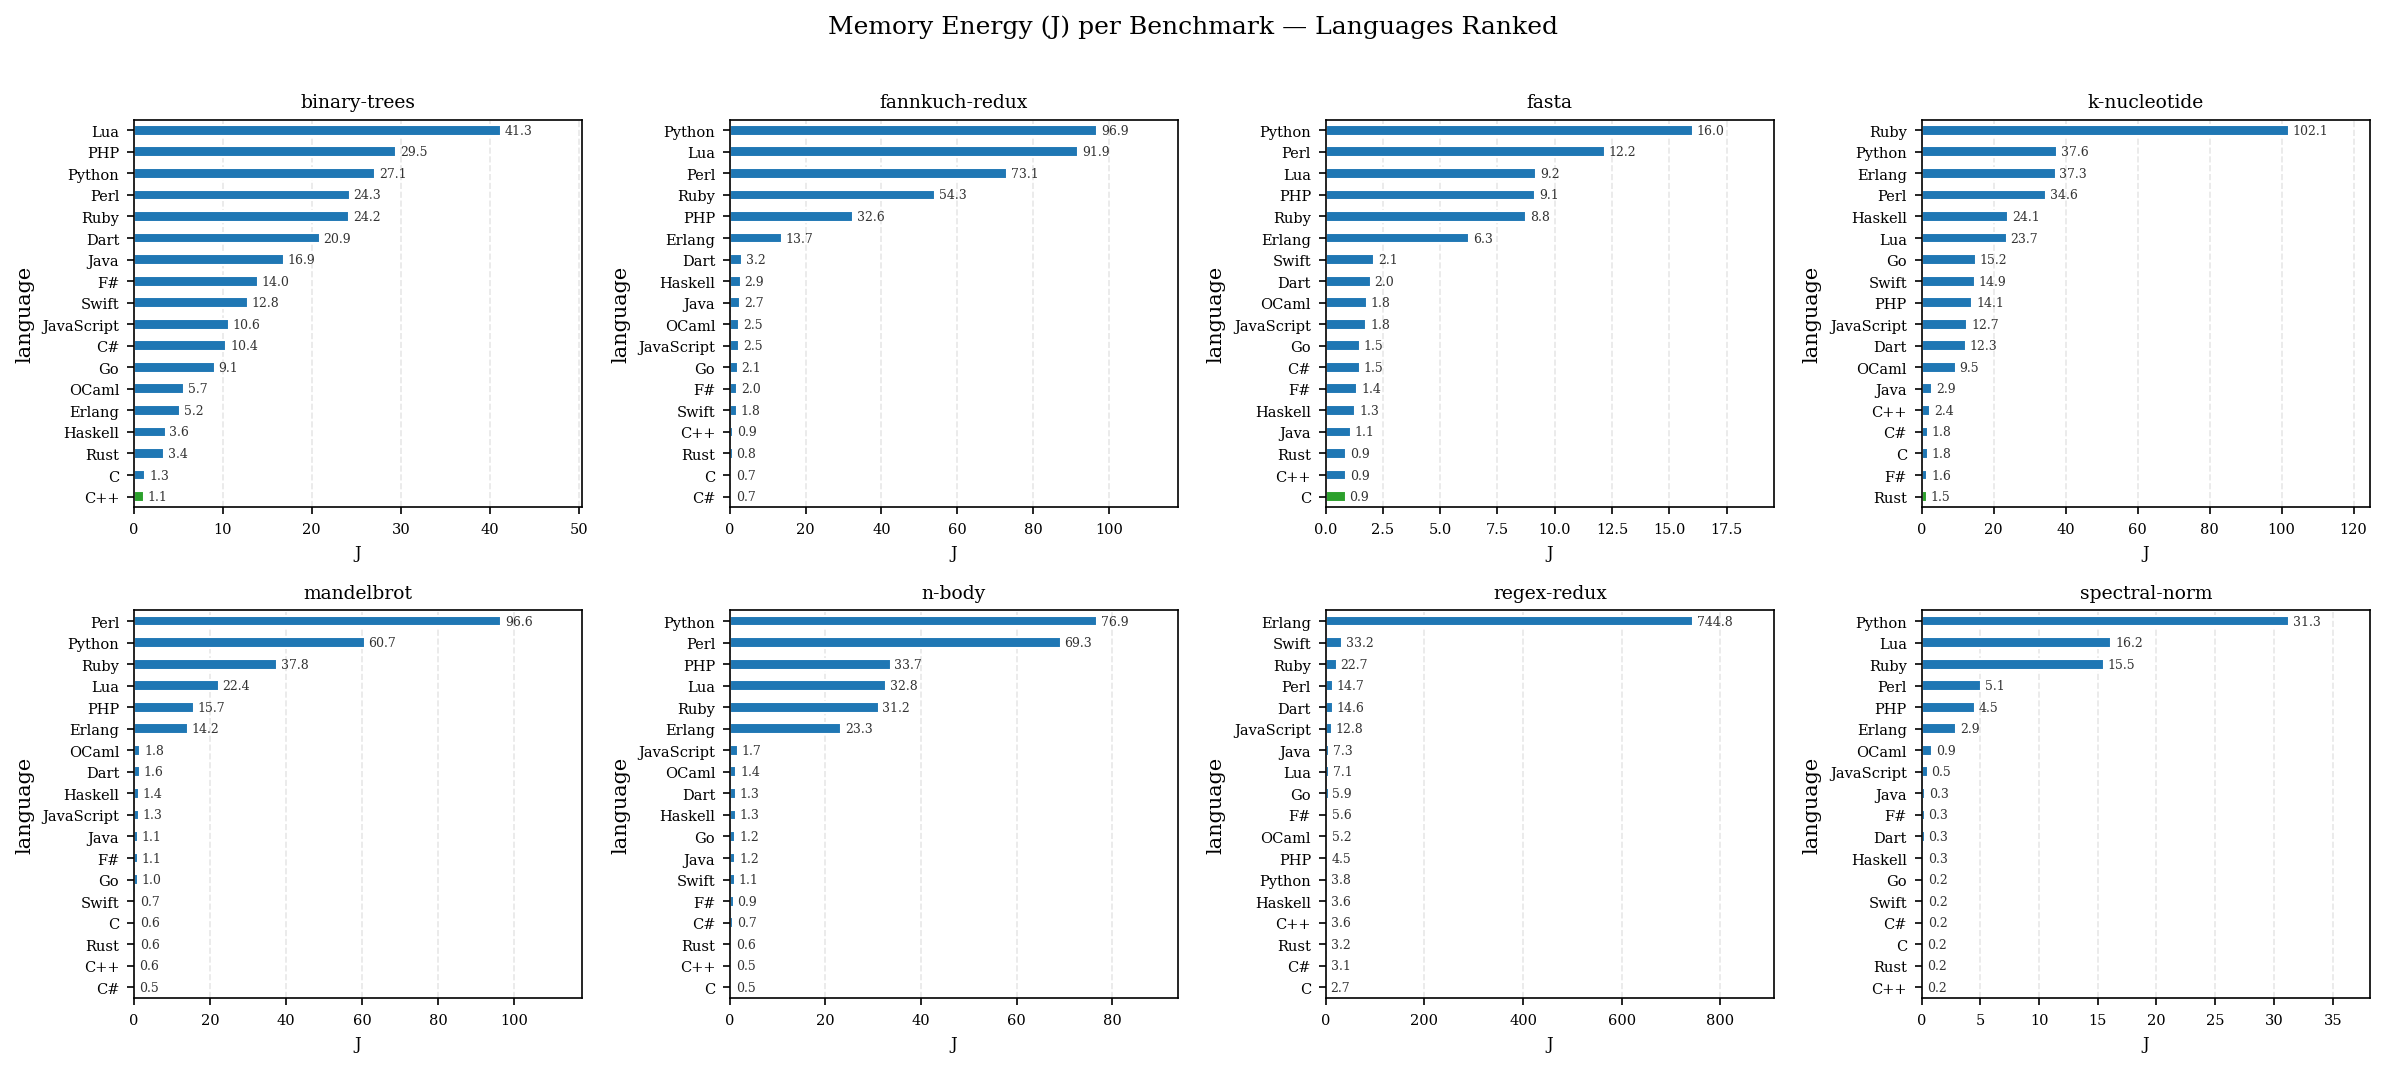

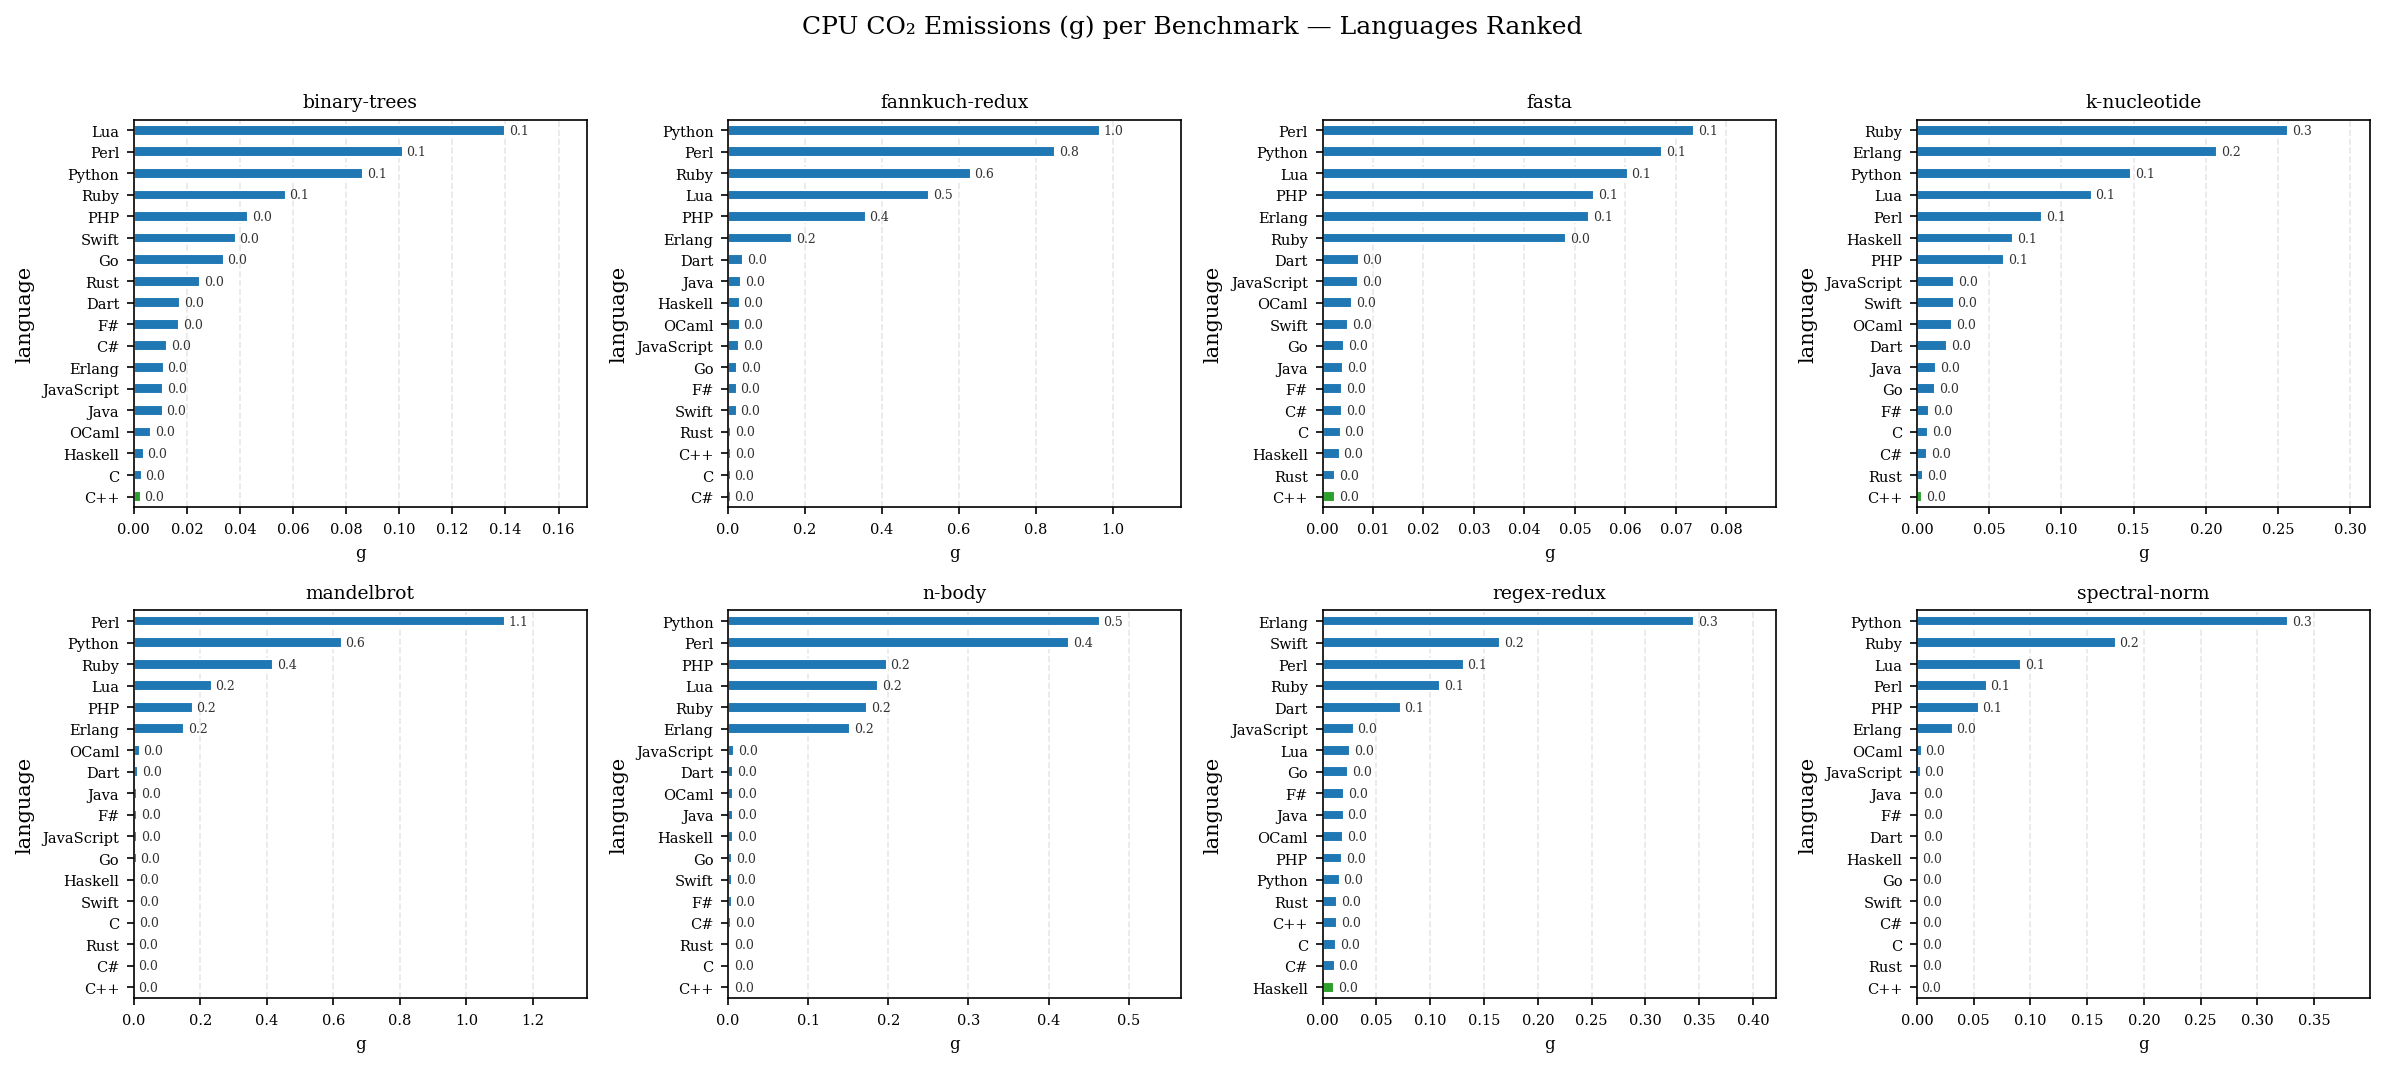

In [10]:
def grid_ranked_bars(metric_col: str, unit_label: str, title: str, fname: str):
    benchmarks = sorted(df['benchmark'].unique())
    ncols = 4
    nrows = int(np.ceil(len(benchmarks) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharey=False)
    axes = axes.flatten()

    for i, bm in enumerate(benchmarks):
        ax = axes[i]
        sub = df[df['benchmark'] == bm].set_index('language')[metric_col].sort_values()
        colors = ['#2ca02c'] + ['#1f77b4'] * (len(sub) - 1)
        sub.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

        # Value labels at the end of each bar
        x_max = sub.max()
        for bar, val in zip(ax.patches, sub.values):
            ax.text(
                bar.get_width() + x_max * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}',
                va='center', ha='left', fontsize=6, color='#333333',
            )

        ax.set_xlim(0, x_max * 1.22)  # make room for labels
        ax.set_title(bm, fontsize=9)
        ax.set_xlabel(unit_label, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.xaxis.grid(True, linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, y=1.01, fontsize=12)
    plt.tight_layout()
    save(fname)

grid_ranked_bars(COL_CPU_ENERGY, 'J',  'CPU Energy (J) per Benchmark — Languages Ranked',          'grid_cpu_energy_per_benchmark')
grid_ranked_bars(COL_TIME,       'ms',  'Execution Time (ms) per Benchmark — Languages Ranked',       'grid_time_per_benchmark')
grid_ranked_bars(COL_MEM_ENERGY, 'J',  'Memory Energy (J) per Benchmark — Languages Ranked',        'grid_mem_energy_per_benchmark')
grid_ranked_bars(COL_CPU_CARBON, 'g',  'CPU CO₂ Emissions (g) per Benchmark — Languages Ranked',   'grid_cpu_carbon_per_benchmark')

In [11]:
# Mean energy and time per language across all 8 benchmarks
agg = df.groupby('language')[[COL_CPU_ENERGY, COL_MEM_ENERGY, COL_TIME]].mean()

# Normalize each metric to the best (lowest) language
agg['CPU Energy Normalized'] = (agg[COL_CPU_ENERGY] / agg[COL_CPU_ENERGY].min()).round(2)
agg['RAM Energy Normalized'] = (agg[COL_MEM_ENERGY] / agg[COL_MEM_ENERGY].min()).round(2)
agg['Time Normalized']       = (agg[COL_TIME]        / agg[COL_TIME].min()).round(2)

# Sort by CPU energy ascending
ranking = (
    agg[['CPU Energy Normalized', 'RAM Energy Normalized', 'Time Normalized']]
    .sort_values('CPU Energy Normalized')
    .reset_index()
    .rename(columns={'language': 'Language'})
)

ranking.index = ranking.index + 1  # rank starts at 1
ranking.index.name = 'Rank'

ranking

,Language,CPU Energy Normalized,RAM Energy Normalized,Time Normalized
Rank,,,,
1,C++,1.00,1.16,1.00
2,C,1.13,1.00,1.02
3,C#,1.38,2.17,1.38
4,Rust,1.70,1.27,1.52
5,F#,2.47,3.08,2.08
6,Java,2.78,3.85,2.55
7,Go,3.18,4.16,3.01
8,OCaml,3.20,3.30,3.19
9,JavaScript,3.42,5.04,3.56


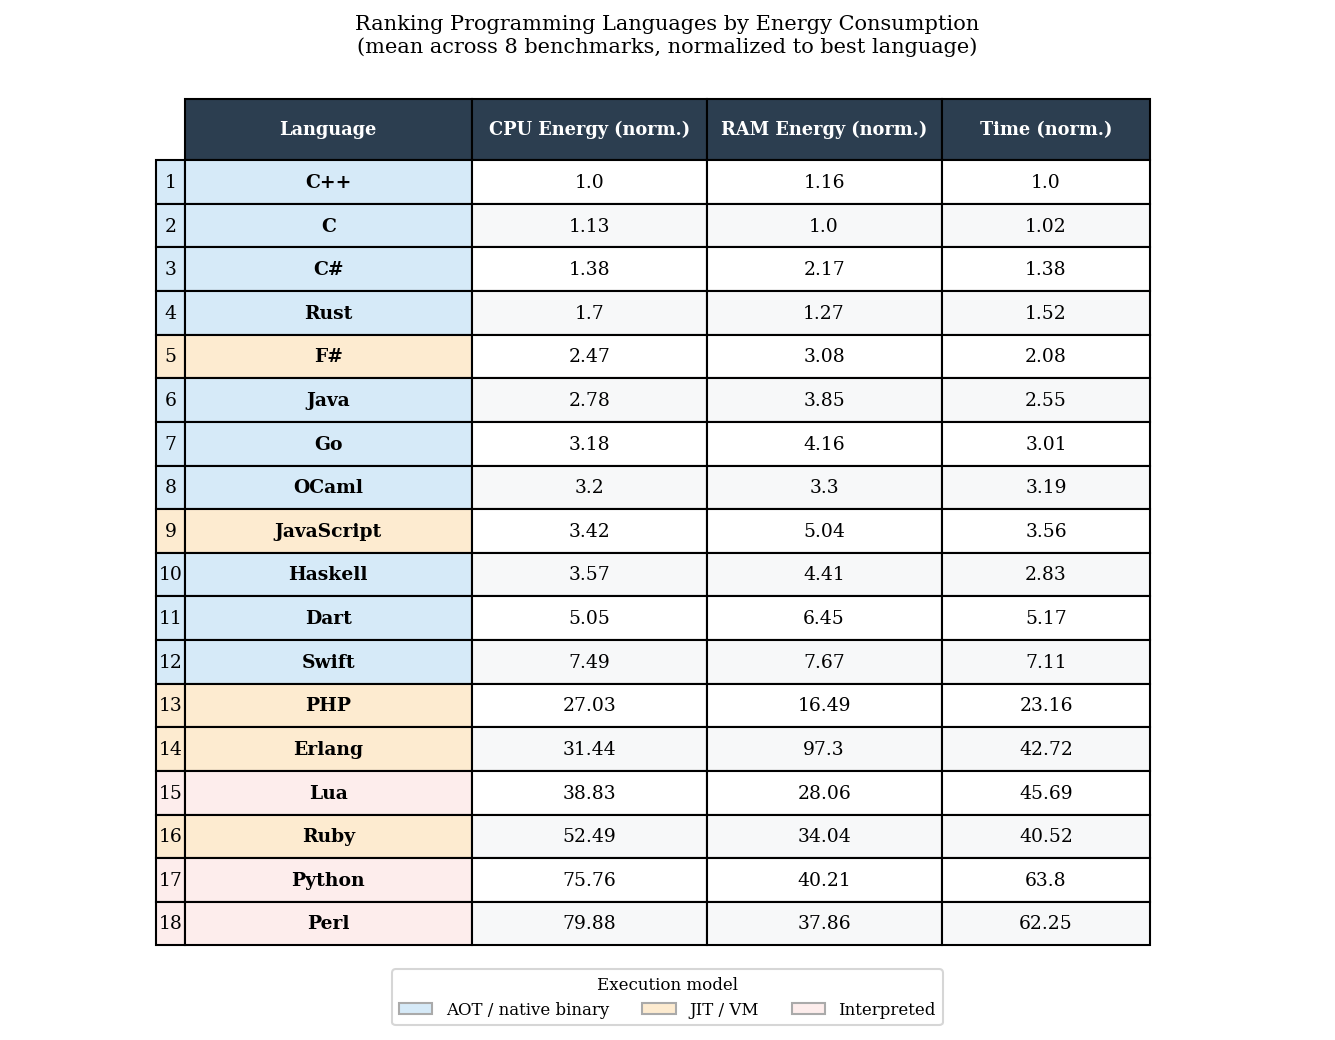

In [12]:
import matplotlib.patches as mpatches

# ── Execution-model classification ───────────────────────────────────────────
AOT         = {'C', 'C++', 'C#', 'Dart', 'Go', 'Haskell', 'Java', 'OCaml', 'Rust', 'Swift'}
JIT_VM      = {'Erlang', 'F#', 'JavaScript', 'PHP', 'Ruby'}
INTERPRETED = {'Lua', 'Perl', 'Python'}

TIER_COLOR = {
    'aot'        : '#d6eaf8',
    'jit'        : '#fdebd0',
    'interpreted': '#fdedec',
}

def tier_color(lang):
    if lang in AOT:         return TIER_COLOR['aot']
    if lang in JIT_VM:      return TIER_COLOR['jit']
    if lang in INTERPRETED: return TIER_COLOR['interpreted']
    return 'white'

# ── Table ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.axis('off')

# Shorter column headers to avoid overlap
col_labels = ['Language', 'CPU Energy (norm.)', 'RAM Energy (norm.)', 'Time (norm.)']

table = ax.table(
    cellText=ranking.values,
    colLabels=col_labels,
    rowLabels=ranking.index,
    cellLoc='center',
    rowLoc='center',
    loc='center',
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Column widths: rank | language | cpu | ram | time
col_widths = [0.06, 0.22, 0.18, 0.18, 0.16]
for col_idx, width in enumerate(col_widths):
    # col -1 is rank label, cols 0-3 are data columns
    actual = col_idx - 1
    for row in range(len(ranking) + 1):
        try:
            table[(row, actual)].set_width(width)
        except KeyError:
            pass

# Header styling
for col in range(len(col_labels)):
    cell = table[(0, col)]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
    cell.set_height(0.07)


# Data rows
for row in range(1, len(ranking) + 1):
    lang = ranking.iloc[row - 1]['Language']
    tc   = tier_color(lang)
    is_even = row % 2 == 0
    for col in range(-1, len(col_labels)):
        cell = table[(row, col)]
        if col <= 0:
            cell.set_facecolor(tc)
            cell.set_text_props(fontweight='bold' if col == 0 else 'normal', fontsize=9)
        else:
            cell.set_facecolor('#f7f8f9' if is_even else 'white')

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=TIER_COLOR['aot'],         edgecolor='#aaa', label='AOT / native binary'),
    mpatches.Patch(facecolor=TIER_COLOR['jit'],         edgecolor='#aaa', label='JIT / VM'),
    mpatches.Patch(facecolor=TIER_COLOR['interpreted'], edgecolor='#aaa', label='Interpreted'),
]
ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    fontsize=8,
    frameon=True,
    title='Execution model',
    title_fontsize=8,
)

ax.set_title(
    'Ranking Programming Languages by Energy Consumption\n'
    '(mean across 8 benchmarks, normalized to best language)',
    fontsize=10, pad=14,
)

plt.tight_layout()
save('ranking_table_energy_time')